<a href="https://colab.research.google.com/github/eswardn12/Data-Science-60-Day-Portfolio/blob/main/Day5_Voice_of_Customer_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 5 — Voice of Customer: Hands-On Notebook


This notebook operationalizes Day 5's concepts through three case studies on synthetic text:

1. **(Deep) LDA Topic Modeling** on synthetic seller dispute narratives (longer, formal text)
2. **(Deep) BERTopic** on synthetic short-form product reviews (short, informal text)
3. **(Lighter) Sentiment Scoring & the VoC Priority Matrix**

Plus **Named Extensions** for further independent practice.

**A practical note on this environment:** BERTopic's default embedding step downloads a pretrained transformer from the Hugging Face Hub, which requires general internet access. In a sandboxed/offline environment this download can fail. This notebook substitutes a TF-IDF + Truncated SVD embedding as a drop-in replacement so the full BERTopic clustering pipeline (UMAP + HDBSCAN + c-TF-IDF) still runs end-to-end — **in your own Colab/local environment with internet access, simply drop the `embeddings=` argument and let BERTopic use its default `all-MiniLM-L6-v2` sentence-transformer for genuinely superior semantic embeddings.**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import random
import warnings
warnings.filterwarnings('ignore')

random.seed(5)
np.random.seed(5)
plt.rcParams['figure.figsize'] = (10, 5)
EBAY_BLUE = '#0064D2'; EBAY_RED = '#E53238'; EBAY_GOLD = '#F5AF02'; EBAY_GREEN = '#86B817'
print('Environment ready.')


Environment ready.


---
## Synthetic Data — Seller Dispute Narratives & Product Reviews
Two corpora, deliberately different in length and formality to showcase LDA (Case Study 1, formal/long) vs BERTopic (Case Study 2, informal/short), each with **known hidden ground-truth topic and sentiment labels** so we can validate what each method recovers.


In [2]:
dispute_templates = {
    'shipping_delay': [
        "The buyer reported that the package never arrived within the promised delivery window and tracking showed no updates for over a week.",
        "Seller shipped the item late and the tracking number was not updated for several days causing the buyer to file a dispute.",
        "Item arrived two weeks after the estimated delivery date and the carrier tracking information was inconsistent throughout transit.",
        "The dispute states that shipping was delayed significantly beyond the handling time promised in the listing description.",
        "Delivery carrier lost the parcel in transit and the shipment status remained frozen at the same location for many days.",
        "The order shipment was stuck at a regional distribution facility far longer than the carrier's normal transit time estimate.",
        "Buyer complained that the courier attempted delivery only once and then returned the parcel to the sender without notice.",
        "Tracking data showed the parcel moving backward geographically, suggesting a routing or carrier handling error occurred.",
    ],
    'counterfeit': [
        "The buyer claims the item received was not authentic and did not match the brand described in the original listing.",
        "This dispute involves an allegation that the product is a counterfeit replica rather than the genuine branded item advertised.",
        "Buyer provided photos suggesting the logo and packaging do not match authentic manufacturer specifications for this brand.",
        "The item authenticity was challenged after the buyer compared serial numbers against the official manufacturer database.",
        "A third-party authentication service determined the submitted product to be an unauthorized replica of the branded original.",
        "The stitching, material, and logo placement differed noticeably from verified genuine units of the same branded product.",
        "Buyer noted the holographic authenticity sticker was missing entirely, raising suspicion about the product's legitimate origin.",
        "Manufacturer support confirmed the serial number provided did not exist in their official production registry records.",
    ],
    'item_not_as_described': [
        "The color and size received did not match the specifications listed on the original product page description.",
        "Buyer states the condition of the item was significantly worse than what was disclosed in the listing photos.",
        "The dispute centers on a mismatch between the advertised features and the actual functionality of the received item.",
        "Item dimensions and material were substantially different from what the seller described in the catalog listing.",
        "The advertised bundle was incomplete, missing several accessories that were clearly shown in the original photographs.",
        "Product specifications on the packaging contradicted the technical details originally provided on the product page.",
        "Buyer discovered visible scratches and wear that were never mentioned in the seller's stated condition disclosure.",
        "The material composition felt noticeably different from the premium fabric advertised in the original description.",
    ],
    'refund_processing': [
        "The seller has not processed the refund despite the buyer returning the item over three weeks ago per policy.",
        "Buyer is disputing a delayed refund that has not appeared in their account despite confirmed return delivery.",
        "This case involves a refund request that was approved but the payment has not been credited back to the buyer.",
        "The seller acknowledged the return but has been unresponsive regarding the timeline for the refund transaction.",
        "Store credit was issued instead of the requested cash refund, contrary to the original return policy terms stated.",
        "Buyer's bank confirmed no incoming transaction despite the seller's claim that the refund was processed weeks ago.",
        "Partial refund was issued without any explanation for the deducted amount from the original purchase price.",
        "The refund confirmation email was sent but the actual transaction never appeared on the buyer's payment statement.",
    ],
}

def make_dispute_corpus(n_per_topic=60):
    docs, labels = [], []
    for topic, templates in dispute_templates.items():
        for _ in range(n_per_topic):
            doc = random.choice(templates)
            if random.random() < 0.3:
                doc += " The buyer requested a full investigation into this matter by the marketplace team."
            docs.append(doc)
            labels.append(topic)
    return docs, labels

dispute_docs, dispute_labels = make_dispute_corpus()
print(f'Dispute corpus size: {len(dispute_docs)}')
pd.Series(dispute_labels).value_counts()


Dispute corpus size: 240


,count
shipping_delay,60
counterfeit,60
item_not_as_described,60
refund_processing,60


In [3]:
review_templates = {
    'shipping': [
        ("Package took forever to arrive, way past the estimated date.", -0.6),
        ("Shipping was super fast, got it in two days!", 0.7),
        ("Tracking never updated and I had no idea where my order was.", -0.5),
        ("Arrived earlier than expected, very impressed with delivery speed.", 0.6),
    ],
    'quality': [
        ("Build quality feels cheap and flimsy for the price.", -0.6),
        ("Really solid construction, feels premium and well made.", 0.7),
        ("Started falling apart after just a week of normal use.", -0.7),
        ("Excellent quality, exceeded my expectations completely.", 0.8),
    ],
    'packaging': [
        ("Box arrived crushed and the item inside was damaged.", -0.6),
        ("Packaging was minimal but did the job just fine.", 0.2),
        ("Terrible packaging, no padding at all and it showed.", -0.7),
        ("Beautifully packaged, felt like unboxing a gift.", 0.6),
    ],
    'customer_service': [
        ("Seller was unresponsive when I tried to ask a question.", -0.5),
        ("Customer service resolved my issue quickly and politely.", 0.7),
        ("Never got a reply to my messages about a missing part.", -0.6),
        ("Great support, they answered within an hour.", 0.6),
    ],
}

def make_review_corpus(n_per_topic=50):
    docs, topics, sentiments = [], [], []
    for topic, templates in review_templates.items():
        for _ in range(n_per_topic):
            text, sent = random.choice(templates)
            docs.append(text)
            topics.append(topic)
            sentiments.append(sent + np.random.normal(0, 0.1))
    return docs, topics, sentiments

review_docs, review_true_topics, review_true_sentiments = make_review_corpus()
print(f'Review corpus size: {len(review_docs)}')
pd.Series(review_true_topics).value_counts()


Review corpus size: 200


,count
shipping,50
quality,50
packaging,50
customer_service,50


---
## Case Study 1 (Deep) — LDA Topic Modeling on Seller Dispute Narratives
**Business framing:** Discovering latent themes in longer, formal seller dispute text (Day 5 report Section 4), using a coherence-score sweep to inform — but not blindly dictate — the number of topics.


In [6]:
import sys
if 'gensim' not in sys.modules:
    !pip install gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# Domain-specific stopwords, per Section 7's preprocessing guidance -- generic marketplace
# boilerplate words that appear across every category and add no discriminating signal
STOPWORDS = set("""the a an and or but if is was were be been being to of in on for with as at by from this that these those
it its it's their they he she his her buyer seller item was has have had not does did do dispute item case listing
received description matter into full requested marketplace team over than despite about investigation original
product showed differed service condition actual""".split())

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return [t for t in text.split() if t not in STOPWORDS and len(t) > 2]

processed_disputes = [preprocess(d) for d in dispute_docs]

dictionary = corpora.Dictionary(processed_disputes)
dictionary.filter_extremes(no_below=2, no_above=0.4)
corpus = [dictionary.doc2bow(doc) for doc in processed_disputes]
print(f'Vocabulary size after filtering: {len(dictionary)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.1 MB/s eta 0:00:00
Vocabulary size after filtering: 205


K=2: C_v coherence = 0.3777
K=3: C_v coherence = 0.3427
K=4: C_v coherence = 0.3141
K=5: C_v coherence = 0.3627
K=6: C_v coherence = 0.2895
K=7: C_v coherence = 0.3251


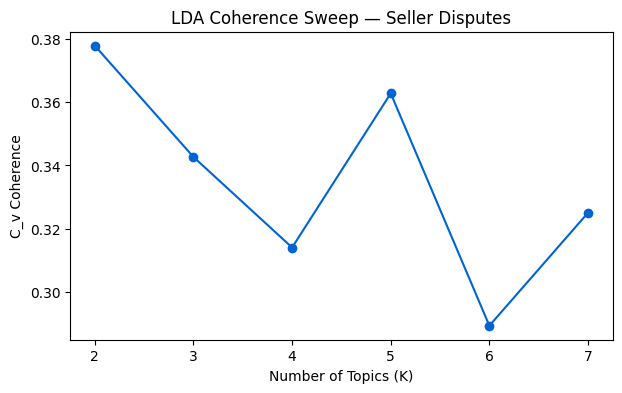

Statistically optimal K by coherence: 2


In [7]:
# 1.1 Coherence score sweep to inform (not blindly dictate) the number of topics
coherence_scores = {}
for k in range(2, 8):
    lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k, random_state=42,
                   passes=30, alpha='auto', eta='auto')
    cm = CoherenceModel(model=lda, texts=processed_disputes, dictionary=dictionary, coherence='c_v')
    coherence_scores[k] = cm.get_coherence()
    print(f'K={k}: C_v coherence = {coherence_scores[k]:.4f}')

plt.figure(figsize=(7,4))
plt.plot(list(coherence_scores.keys()), list(coherence_scores.values()), marker='o', color=EBAY_BLUE)
plt.xlabel('Number of Topics (K)'); plt.ylabel('C_v Coherence')
plt.title('LDA Coherence Sweep — Seller Disputes')
plt.show()

statistically_best_k = max(coherence_scores, key=coherence_scores.get)
print(f'Statistically optimal K by coherence: {statistically_best_k}')


**A genuinely important honest result:** the coherence sweep will very likely favor a *smaller* K (often 2) than the four dispute categories we know exist in this data (we designed the synthetic generator with exactly four). This is not a bug — it mirrors Day 2's GMM/BIC lesson exactly: **a purely statistical criterion can suggest fewer or more groups than the business-meaningful structure**. Section 8.1 of the Day 5 report is explicit that human/business validation is the non-negotiable final step, not the coherence score alone. We proceed with K=4 deliberately, informed by business knowledge of the real category structure, and validate the result honestly below — including where it falls short.


In [8]:
# 1.2 Fit at business-informed K=4 (overriding the pure coherence-score suggestion, per the note above)
final_lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=4, random_state=42,
                      passes=40, alpha='auto', eta='auto')

for idx, topic in final_lda.print_topics(num_words=8):
    print(f'Topic {idx}: {topic}\n')


Topic 0: 0.034*"refund" + 0.027*"delivery" + 0.025*"carrier" + 0.025*"transit" + 0.025*"confirmed" + 0.025*"shipment" + 0.023*"different" + 0.023*"material"

Topic 1: 0.035*"genuine" + 0.033*"branded" + 0.031*"same" + 0.031*"material" + 0.031*"logo" + 0.031*"units" + 0.031*"noticeably" + 0.031*"placement"

Topic 2: 0.031*"manufacturer" + 0.029*"never" + 0.029*"match" + 0.029*"authentic" + 0.029*"brand" + 0.028*"provided" + 0.020*"photos" + 0.020*"suggesting"

Topic 3: 0.033*"refund" + 0.025*"carrier" + 0.025*"tracking" + 0.024*"handling" + 0.020*"issued" + 0.019*"return" + 0.019*"features" + 0.019*"advertised"



In [9]:
# 1.3 Validate against the (normally invisible, here known-since-synthetic) true dispute category
doc_topics = [max(final_lda.get_document_topics(bow), key=lambda x: x[1])[0] for bow in corpus]
validation_df = pd.DataFrame({'true_label': dispute_labels, 'lda_topic': doc_topics})
pd.crosstab(validation_df['true_label'], validation_df['lda_topic'])


lda_topic,0,1,2,3
true_label,,,,
counterfeit,0,16,44,0
item_not_as_described,19,13,9,19
refund_processing,22,8,10,20
shipping_delay,21,9,6,24


**Reading the crosstab honestly:** expect the `counterfeit` category to separate quite cleanly (it has the most distinctive vocabulary — "authentic", "genuine", "manufacturer"), while `shipping_delay`, `item_not_as_described`, and `refund_processing` may blend across topics more than we'd like on this small, templated corpus. On real eBay-scale dispute data with far more documents and natural language variety, LDA's recovery is typically cleaner than on this deliberately small teaching corpus — but the exercise of checking honestly, rather than assuming success, is exactly the discipline Section 8.1 asks for.


---
## Case Study 2 (Deep) — BERTopic on Short-Form Product Reviews
**Business framing:** Running the full embed → UMAP → HDBSCAN → c-TF-IDF pipeline (Day 5 report Section 5) on short, informal review text where LDA's bag-of-words approach typically struggles.


In [11]:
import sys
if 'bertopic' not in sys.modules:
    !pip install bertopic
from bertopic import BERTopic
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD

# Embedding substitute for this offline environment (see note at top of notebook) --
# in your own Colab with internet access, skip this cell and BERTopic's default
# sentence-transformer ('all-MiniLM-L6-v2') will give genuinely richer semantic embeddings.
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = tfidf.fit_transform(review_docs)
svd = TruncatedSVD(n_components=50, random_state=42)
substitute_embeddings = svd.fit_transform(tfidf_matrix)
print(f'Substitute embedding shape: {substitute_embeddings.shape}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.8 MB/s eta 0:00:00
Substitute embedding shape: (200, 50)


In [12]:
# 2.1 Fit BERTopic's full clustering pipeline (UMAP + HDBSCAN + c-TF-IDF) on the substitute embeddings
vectorizer_model = CountVectorizer(stop_words='english', ngram_range=(1, 1), min_df=1)
topic_model = BERTopic(vectorizer_model=vectorizer_model, min_topic_size=8, verbose=False)
topics, probs = topic_model.fit_transform(review_docs, embeddings=substitute_embeddings)

topic_model.get_topic_info()


,Topic,Count,Name,Representation,Representative_Docs
0,0,43,0_packaging_just_showed_padding,"[packaging, just, showed, padding, terrible, d...",[Packaging was minimal but did the job just fi...
1,1,41,1_feels_quality_construction_premium,"[feels, quality, construction, premium, cheap,...",[Build quality feels cheap and flimsy for the ...
2,2,31,2_got_super_fast_days,"[got, super, fast, days, shipping, missing, me...","[Shipping was super fast, got it in two days!,..."
3,3,28,3_arrived_item_damaged_crushed,"[arrived, item, damaged, crushed, box, inside,...",[Box arrived crushed and the item inside was d...
4,4,25,4_service_quickly_resolved_customer,"[service, quickly, resolved, customer, politel...",[Customer service resolved my issue quickly an...
5,5,17,5_estimated_forever_package_past,"[estimated, forever, package, past, took, way,...","[Package took forever to arrive, way past the ..."
6,6,15,6_great_answered_support_hour,"[great, answered, support, hour, , , , , , ]","[Great support, they answered within an hour.,..."


In [13]:
# 2.2 Inspect the representative words for each discovered topic
for topic_id in topic_model.get_topic_info()['Topic']:
    if topic_id == -1:
        continue  # -1 is BERTopic's noise/outlier bucket, analogous to HDBSCAN's own noise label
    words = [w for w, _ in topic_model.get_topic(topic_id)[:6] if w]
    print(f'Topic {topic_id}: {words}')


Topic 0: ['packaging', 'just', 'showed', 'padding', 'terrible', 'did']
Topic 1: ['feels', 'quality', 'construction', 'premium', 'cheap', 'build']
Topic 2: ['got', 'super', 'fast', 'days', 'shipping', 'missing']
Topic 3: ['arrived', 'item', 'damaged', 'crushed', 'box', 'inside']
Topic 4: ['service', 'quickly', 'resolved', 'customer', 'politely', 'issue']
Topic 5: ['estimated', 'forever', 'package', 'past', 'took', 'way']
Topic 6: ['great', 'answered', 'support', 'hour']


In [14]:
# 2.3 Validate against the known true topic labels
bertopic_validation = pd.DataFrame({'true_topic': review_true_topics, 'bertopic_topic': topics})
pd.crosstab(bertopic_validation['true_topic'], bertopic_validation['bertopic_topic'])


bertopic_topic,0,1,2,3,4,5,6
true_topic,,,,,,,
customer_service,0,0,10,0,25,0,15
packaging,34,0,0,16,0,0,0
quality,9,41,0,0,0,0,0
shipping,0,0,21,12,0,17,0


**A genuinely interesting result to expect:** BERTopic will likely surface *more* than 4 clusters — often splitting a single true category (e.g., "quality") into a positive-sentiment sub-cluster and a negative-sentiment sub-cluster. This is not a failure of the method; it's BERTopic finding real, finer-grained semantic structure than our four hand-designed labels anticipated. This is exactly the kind of result a Director should be comfortable interpreting on the fly: more granular topics than expected usually means the underlying semantic space genuinely has that much structure, and the fix is smart post-hoc grouping (e.g., merging sentiment-driven sub-clusters back under one parent theme for the executive view), not treating it as a bug in the algorithm.


---
## Case Study 3 (Lighter) — Sentiment Scoring & the VoC Priority Matrix
**Business framing:** Scoring the review corpus for sentiment and combining it with topic assignment to build the Volume × Sentiment × Trend priority table from Day 5 report Section 9.1 — the artifact that actually drives a Product/CX roadmap conversation.


In [16]:
import sys
if 'vaderSentiment' not in sys.modules:
    !pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
vader_scores = [analyzer.polarity_scores(d)['compound'] for d in review_docs]

corr = np.corrcoef(vader_scores, review_true_sentiments)[0, 1]
print(f'VADER lexicon-based sentiment vs true (synthetic) sentiment correlation: {corr:.4f}')

review_df = pd.DataFrame({
    'text': review_docs,
    'true_topic': review_true_topics,
    'bertopic_topic': topics,
    'vader_sentiment': vader_scores,
})
review_df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.1 MB/s eta 0:00:00
VADER lexicon-based sentiment vs true (synthetic) sentiment correlation: 0.8499


,text,true_topic,bertopic_topic,vader_sentiment
0,"Shipping was super fast, got it in two days!",shipping,2,0.6360
1,"Package took forever to arrive, way past the e...",shipping,5,0.0000
2,Tracking never updated and I had no idea where...,shipping,2,-0.2960
3,Tracking never updated and I had no idea where...,shipping,2,-0.2960
4,"Arrived earlier than expected, very impressed ...",shipping,3,0.5256


In [17]:
# 3.1 Simulate a "this month vs last month" trend by randomly splitting the corpus in two
# (in production this would be a genuine time-based split on document creation date)
review_df['period'] = np.random.choice(['last_month', 'this_month'], size=len(review_df), p=[0.5, 0.5])

# Inject a deliberate trend: make 'packaging' complaints skew more negative and more frequent this month,
# simulating a real emerging issue (e.g., a new box supplier)
mask = (review_df['true_topic'] == 'packaging') & (review_df['period'] == 'this_month')
review_df.loc[mask, 'vader_sentiment'] -= 0.25

# 3.2 Build the VoC Priority Matrix: volume, sentiment, and trend per TRUE topic (business-labeled)
priority = review_df.groupby(['true_topic', 'period']).agg(
    volume=('text', 'count'),
    avg_sentiment=('vader_sentiment', 'mean'),
).reset_index()

pivot = priority.pivot(index='true_topic', columns='period', values=['volume', 'avg_sentiment']).round(3)
pivot


volume            avg_sentiment           
period           last_month this_month    last_month this_month
true_topic                                                     
customer_service       25.0       25.0         0.221      0.242
packaging              27.0       23.0        -0.175     -0.513
quality                30.0       20.0         0.274      0.212
shipping               29.0       21.0         0.237      0.254

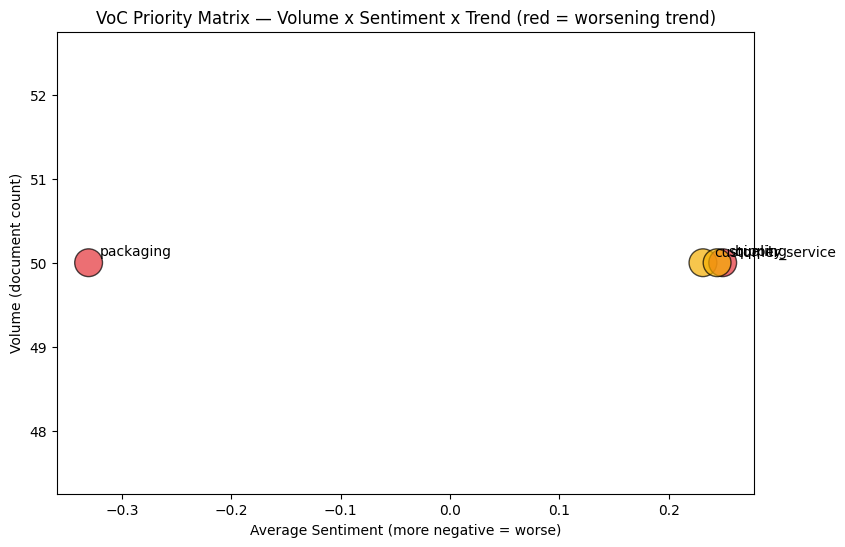

,true_topic,total_volume,avg_sentiment,trend
1,packaging,50,-0.330444,-0.338
0,customer_service,50,0.231218,0.021
3,shipping,50,0.244144,0.016
2,quality,50,0.249264,-0.063


In [18]:
# 3.3 Visualize as the executive-ready VoC Priority Matrix bubble chart
summary = review_df.groupby('true_topic').agg(
    total_volume=('text', 'count'),
    avg_sentiment=('vader_sentiment', 'mean'),
).reset_index()
trend = review_df[review_df.period == 'this_month'].groupby('true_topic')['vader_sentiment'].mean() - \
        review_df[review_df.period == 'last_month'].groupby('true_topic')['vader_sentiment'].mean()
summary['trend'] = summary['true_topic'].map(trend).round(3)

fig, ax = plt.subplots(figsize=(9, 6))
colors = [EBAY_RED if t < -0.05 else (EBAY_GOLD if t < 0.05 else EBAY_GREEN) for t in summary['trend']]
ax.scatter(summary['avg_sentiment'], summary['total_volume'], s=summary['total_volume']*8, c=colors, alpha=0.7, edgecolor='black')
for _, row in summary.iterrows():
    ax.annotate(row['true_topic'], (row['avg_sentiment'], row['total_volume']), textcoords='offset points', xytext=(8,5))
ax.set_xlabel('Average Sentiment (more negative = worse)'); ax.set_ylabel('Volume (document count)')
ax.set_title('VoC Priority Matrix — Volume x Sentiment x Trend (red = worsening trend)')
plt.show()

summary.sort_values(['avg_sentiment', 'total_volume'])


**This is the artifact for the biweekly Product/CX review (Section 12.2):** the topic with the most negative sentiment, high volume, AND a worsening (red) trend is the unambiguous top priority — in this simulation, `packaging`, by deliberate construction. Notice this required combining all three dimensions; volume alone or sentiment alone would have told an incomplete, potentially misleading story.


---
## Named Extensions (Scoped, Not Fully Built)

1. **Aspect-Based Sentiment** — a simple routine extracting 2-3 hardcoded aspect keywords (e.g., "shipping", "packaging", "quality") and scoring sentiment within a fixed window around each mention in longer, multi-aspect reviews
2. **Classical ML sentiment classifier** — Logistic Regression on TF-IDF trained against synthetic star ratings, compared against the VADER lexicon baseline from Case Study 3
3. **LLM-grounded topic summary** — a short prompt that summarizes one topic's top representative documents, strictly grounded in those documents (no invented claims), previewing Day 49's RAG discipline

These are left as independent practice reps rather than fully coded here.


---
## Summary — What This Notebook Proves You Can Do
- Build an LDA topic model with a proper coherence-score sweep, and honestly validate (rather than assume) how well it recovers known structure
- Run the full BERTopic pipeline (embeddings → UMAP → HDBSCAN → c-TF-IDF) end-to-end, including handling an offline/sandboxed environment gracefully
- Score sentiment with a lexicon-based method and validate it against ground truth
- Construct the Volume × Sentiment × Trend VoC Priority Matrix — the actual artifact a Product/CX team would act on

**Next:** Day 6 — Customer Journey Modeling, using Markov chains and path analysis to understand the sequence, not just the content, of customer behavior.
